In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [11]:
df = pd.read_csv("Datasets/insurance.csv")

In [5]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nHead:\n", df.head())

Shape: (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Head:
    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [6]:
# --- Encode Categorical Features ---
df_encoded = pd.get_dummies(df, drop_first=True)

In [7]:
# --- Features & Target ---
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

In [8]:
# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Train Linear Regression ---
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# --- Evaluation ---
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nMean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)


Mean Absolute Error (MAE): 4181.194473753649
Root Mean Squared Error (RMSE): 5796.284659276273


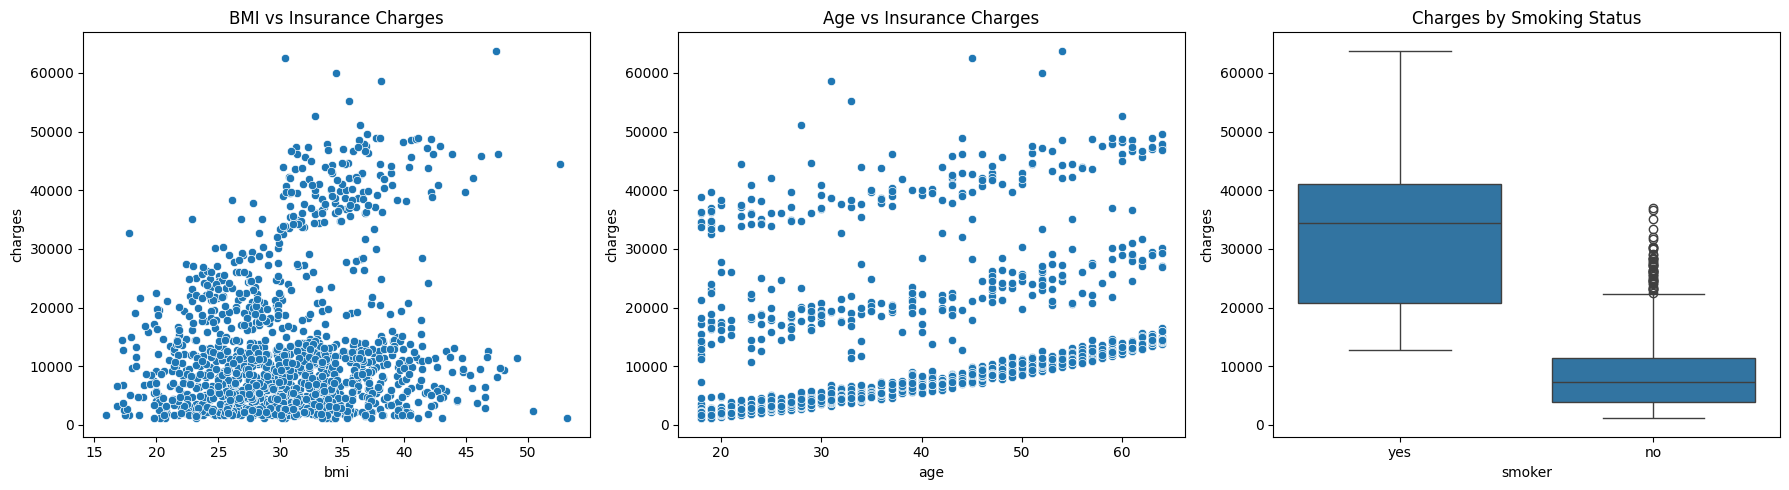

In [10]:
# --- Visualizations ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 row, 3 columns

# Scatter plot: BMI vs Charges
sns.scatterplot(x="bmi", y="charges", data=df, ax=axes[0])
axes[0].set_title("BMI vs Insurance Charges")

# Scatter plot: Age vs Charges
sns.scatterplot(x="age", y="charges", data=df, ax=axes[1])
axes[1].set_title("Age vs Insurance Charges")

# Box plot: Charges by Smoking Status
sns.boxplot(x="smoker", y="charges", data=df, ax=axes[2])
axes[2].set_title("Charges by Smoking Status")

plt.tight_layout()
plt.show()